# LSTM Model Evaluation Notebook
Load a trained model checkpoint and visualize predictions on validation data

## 1. Configuration
Update these settings to match your model and data paths

In [2]:
# ============================================================================
# CONFIGURATION - UPDATE THESE!
# ============================================================================

# Path to your best model checkpoint
MODEL_CHECKPOINT = "C:/Github_FabianDubach/aicomp-flextrack/sweep/lstm_sweep-2025-11-13_12-25-57/best_model/best_model.pt"

# Model architecture (must match the saved model)
MODEL_CONFIG = {
    'input_size': 37,      # Number of features
    'hidden_size': 32,     # Hidden layer size from best run
    'num_layers': 2,       # Number of LSTM layers from best run
    'output_size': 1,      # Output size
    'dropout': 0.4215393172832361,        # Dropout from best run
    'sequence_length': 12  # Sequence length
}

# Data paths
DATA_PATH = "C:/Github_FabianDubach/aicomp-flextrack/data/regression/"

# Constants
ENTRIES_PER_DAY = 53  # 15 min intervals from 6:00 to 19:00

## 2. Imports and Setup

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

# Add path for comp_metrics
sys.path.append('C:/Github_FabianDubach/aicomp-flextrack/src/evaluation')
from comp_metrics import evaluate_all_metrics

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 3. Model Definition
Must match your training script exactly

In [4]:
class SimpleRNN(nn.Module):
    """LSTM model for regression"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        out = torch.relu(out)
        return out

print("✅ Model class defined")

✅ Model class defined


## 4. Data Processing Functions

In [5]:
def add_time_features(df):
    """Add temporal features to the dataframe"""
    australian_holidays = holidays.AU()
    
    df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local'])
    df['hour'] = df['Timestamp_Local'].dt.hour
    df['minute'] = df['Timestamp_Local'].dt.minute
    df['month'] = df['Timestamp_Local'].dt.month
    df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek
    df['is_weekend'] = df['Timestamp_Local'].dt.dayofweek >= 5
    df['is_holiday'] = df['Timestamp_Local'].dt.date.apply(lambda x: x in australian_holidays)
    return df


def engineer_features(df):
    """Complete feature engineering pipeline"""
    df = add_time_features(df)
    
    # Remove night entries (6 AM to 7 PM only)
    df = df[
        ((df['hour'] > 6) & (df['hour'] < 19)) |
        ((df['hour'] == 6) & (df['minute'] >= 0)) |
        ((df['hour'] == 19) & (df['minute'] == 0))
    ].copy()
    
    # Cyclic encoding for month
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] / 12))
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] / 12))
    df.drop(columns=['month'], inplace=True)
    
    # Difference features
    df['Building_Power_kW_diff_15min'] = df.groupby('Site')['Building_Power_kW'].diff(1)
    df['Building_Power_kW_diff_1h'] = df.groupby('Site')['Building_Power_kW'].diff(4)
    df['Building_Power_kW_diff_1d'] = df.groupby('Site')['Building_Power_kW'].diff(ENTRIES_PER_DAY)
    df['Dry_Bulb_Temperature_C_diff_15min'] = df.groupby('Site')['Dry_Bulb_Temperature_C'].diff(1)
    df['Global_Horizontal_Radiation_W/m2_diff_15min'] = df.groupby('Site')['Global_Horizontal_Radiation_W/m2'].diff(1)
    
    # Rolling statistics
    group = df.groupby('Site')['Building_Power_kW']
    df['Building_Power_kW_rolling_mean_1h'] = group.rolling(4).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_mean_2h'] = group.rolling(8).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_mean_1d'] = group.rolling(ENTRIES_PER_DAY).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_1h'] = group.rolling(4).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_2h'] = group.rolling(8).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_1d'] = group.rolling(ENTRIES_PER_DAY).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_min_1h'] = group.rolling(4).min().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_min_2h'] = group.rolling(8).min().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_max_1h'] = group.rolling(4).max().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_max_2h'] = group.rolling(8).max().reset_index(level=0, drop=True)
    
    # One-hot encodings
    df = pd.get_dummies(df, columns=['minute', 'day_of_week'])
    df = pd.get_dummies(df, columns=['Demand_Response_Flag'])
    df['is_holiday'] = df['is_holiday'].astype(int)
    df['is_weekend'] = df['is_weekend'].astype(int)
    
    return df


def prepare_data(df):
    """Prepare and normalize data"""
    continuous_feature_columns = [
        'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
        'Building_Power_kW_diff_15min', 'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d',
        'Dry_Bulb_Temperature_C_diff_15min', 'Global_Horizontal_Radiation_W/m2_diff_15min',
        'Building_Power_kW_rolling_mean_1h', 'Building_Power_kW_rolling_mean_2h', 'Building_Power_kW_rolling_mean_1d',
        'Building_Power_kW_rolling_std_1h', 'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d',
        'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h', 
        'Building_Power_kW_rolling_max_1h', 'Building_Power_kW_rolling_max_2h', 'hour'
    ]
    
    categorical_feature_columns = [
        'minute_0', 'minute_15', 'minute_30', 'minute_45',
        'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 
        'day_of_week_4', 'day_of_week_5', 'day_of_week_6',
        'Demand_Response_Flag_-1', 'Demand_Response_Flag_0', 'Demand_Response_Flag_1',
        'is_weekend', 'is_holiday'
    ]
    
    cyclic_feature_columns = ['month_sin', 'month_cos']
    target_column = 'Demand_Response_Capacity_kW'
    
    # Extract features
    X_continuous = df[continuous_feature_columns].values
    X_categorical = df[categorical_feature_columns].values
    X_cyclic = df[cyclic_feature_columns].values
    y = df[target_column].values.reshape(-1, 1)
    
    # Scale continuous features and target
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_scaled = scaler_X.fit_transform(X_continuous)
    y = scaler_y.fit_transform(y)
    
    # Concatenate all features
    X = np.concatenate([X_scaled, X_categorical, X_cyclic], axis=1)
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    # Remove incomplete entries (first day of each site)
    mask = np.ones(len(X), dtype=bool)
    mask[0:ENTRIES_PER_DAY] = False  # Site A
    site_b_start = 365 * ENTRIES_PER_DAY
    mask[site_b_start:site_b_start + ENTRIES_PER_DAY] = False  # Site B
    site_c_start = 730 * ENTRIES_PER_DAY
    mask[site_c_start:site_c_start + ENTRIES_PER_DAY] = False  # Site C
    
    X = X[mask]
    y = y[mask]
    
    return X, y, scaler_X, scaler_y


def split_data(X, y):
    """Split data into train and validation sets"""
    site_a_entries = (365 - 1) * ENTRIES_PER_DAY
    site_b_entries = (365 - 1) * ENTRIES_PER_DAY
    train_end_idx = site_a_entries + site_b_entries
    
    X_train = X[:train_end_idx]
    X_val = X[train_end_idx:]
    y_train = y[:train_end_idx]
    y_val = y[train_end_idx:]
    
    return X_train, X_val, y_train, y_val


def create_sequences(X, y, sequence_length):
    """Create sequences for RNN"""
    X_seq = []
    y_seq = []
    
    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i+sequence_length])
        y_seq.append(y[i+sequence_length])
    
    return np.array(X_seq), np.array(y_seq)

print("✅ Data processing functions defined")

✅ Data processing functions defined


## 5. Load and Process Data

In [6]:
print("Loading data...")
df_train = pd.read_csv(f"{DATA_PATH}regression-train.csv")

print("Engineering features...")
df_train = engineer_features(df_train)

print("Preparing data...")
X, y, scaler_X, scaler_y = prepare_data(df_train)

print("Splitting data...")
X_train, X_val, y_train, y_val = split_data(X, y)

print("Creating sequences...")
sequence_length = MODEL_CONFIG['sequence_length']
X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, sequence_length)

print(f"\n✅ Data loaded:")
print(f"   Training samples: {len(X_train_seq)}")
print(f"   Validation samples: {len(X_val_seq)}")
print(f"   Input features: {X_val_seq.shape[2]}")

Loading data...
Engineering features...
Preparing data...
Splitting data...
Creating sequences...

✅ Data loaded:
   Training samples: 38572
   Validation samples: 19280
   Input features: 37


In [7]:
# Extract metadata for metrics
val_building_power_scaled = X_val_seq[:, -1, 2]
temp = np.zeros((len(val_building_power_scaled), 19))
temp[:, 2] = val_building_power_scaled
val_building_power = scaler_X.inverse_transform(temp)[:, 2]

val_demand_flags = np.argmax(X_val_seq[:, -1, 30:33], axis=1) - 1
val_sites = np.array(['Site C'] * len(X_val_seq))

print("✅ Metadata extracted:")
print(f"   Demand flags unique: {np.unique(val_demand_flags)} (expected: [-1, 0, 1])")
print(f"   Building power range: [{val_building_power.min():.2f}, {val_building_power.max():.2f}] kW")

✅ Metadata extracted:
   Demand flags unique: [-1  0  1] (expected: [-1, 0, 1])
   Building power range: [56.33, 496.83] kW


## 6. Load Model and Make Predictions

In [8]:
# Load model
print(f"Loading model from: {MODEL_CHECKPOINT}")
model = SimpleRNN(
    input_size=MODEL_CONFIG['input_size'],
    hidden_size=MODEL_CONFIG['hidden_size'],
    num_layers=MODEL_CONFIG['num_layers'],
    output_size=MODEL_CONFIG['output_size'],
    dropout=MODEL_CONFIG['dropout']
).to(device)

try:
    model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=device))
    print("✅ Model loaded successfully!")
    print(f"\nModel architecture:")
    print(model)
except FileNotFoundError:
    print(f"❌ ERROR: Model file not found at {MODEL_CHECKPOINT}")
    print("Please update MODEL_CHECKPOINT path in the first cell.")
except Exception as e:
    print(f"❌ ERROR loading model: {e}")

Loading model from: C:/Github_FabianDubach/aicomp-flextrack/sweep/lstm_sweep-2025-11-13_12-25-57/best_model/best_model.pt
✅ Model loaded successfully!

Model architecture:
SimpleRNN(
  (lstm): LSTM(37, 32, num_layers=2, batch_first=True, dropout=0.4215393172832361)
  (dropout): Dropout(p=0.4215393172832361, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [9]:
# Make predictions
print("Making predictions...")
model.eval()
X_val_tensor = torch.FloatTensor(X_val_seq).to(device)

with torch.no_grad():
    predictions_scaled = model(X_val_tensor).cpu().numpy()

# Inverse transform
predictions = scaler_y.inverse_transform(predictions_scaled).flatten()
targets = scaler_y.inverse_transform(y_val_seq).flatten()

print(f"✅ Generated {len(predictions)} predictions")
print(f"   Prediction range: [{predictions.min():.2f}, {predictions.max():.2f}] kW")
print(f"   Target range: [{targets.min():.2f}, {targets.max():.2f}] kW")
print(f"   Prediction std: {predictions.std():.2f} kW")

Making predictions...
✅ Generated 19280 predictions
   Prediction range: [-0.15, 0.08] kW
   Target range: [-129.42, 148.02] kW
   Prediction std: 0.04 kW


## 7. Evaluation Metrics

In [10]:
# Competition metrics
metrics = evaluate_all_metrics(
    y_true=targets,
    y_pred=predictions,
    site_labels=val_sites,
    building_power=val_building_power,
    demand_flags=val_demand_flags
)

print("=" * 80)
print("DETAILED EVALUATION METRICS")
print("=" * 80)

print(f"\n📊 Competition Metrics:")
print(f"   NMAE (range):  {metrics['nmae_range']:.2f}%")
print(f"   NMAE (mean):   {metrics['nmae_mean']:.2f}%")
print(f"   NRMSE (range): {metrics['nrmse_range']:.2f}%")
print(f"   NRMSE (mean):  {metrics['nrmse_mean']:.2f}%")
print(f"   Geometric Mean Score: {metrics['geometric_mean_score']:.4f}")
print(f"   F1 Score: {metrics['f1_score']:.4f}")

# Basic statistics
mae = np.abs(targets - predictions).mean()
rmse = np.sqrt(((targets - predictions) ** 2).mean())

print(f"\n📈 Basic Statistics:")
print(f"   MAE:  {mae:.4f} kW")
print(f"   RMSE: {rmse:.4f} kW")
print(f"   Mean Actual:     {targets.mean():.4f} kW")
print(f"   Mean Predicted:  {predictions.mean():.4f} kW")
print(f"   Std Actual:      {targets.std():.4f} kW")
print(f"   Std Predicted:   {predictions.std():.4f} kW")

# Zero analysis
true_zeros = (targets == 0).sum()
pred_zeros = (predictions < 0.5).sum()

print(f"\n🎯 Zero Prediction Analysis:")
print(f"   Actual zeros:    {true_zeros} ({true_zeros/len(targets)*100:.1f}%)")
print(f"   Predicted zeros: {pred_zeros} ({pred_zeros/len(predictions)*100:.1f}%)")

# Non-zero performance
nonzero_mask = targets > 0
if nonzero_mask.sum() > 0:
    nonzero_mae = np.abs(targets[nonzero_mask] - predictions[nonzero_mask]).mean()
    print(f"\n🔥 Performance on Non-Zero Events:")
    print(f"   MAE on non-zero: {nonzero_mae:.4f} kW")
    print(f"   Number of non-zero events: {nonzero_mask.sum()}")

# Horizontal line check
if predictions.std() < 1.0:
    print(f"\n⚠️  WARNING: Nearly horizontal predictions detected!")
    print(f"   Prediction std: {predictions.std():.4f} (should be > 5.0)")
else:
    print(f"\n✅ Prediction variance looks healthy: {predictions.std():.4f}")

print("=" * 80)

DETAILED EVALUATION METRICS

📊 Competition Metrics:
   NMAE (range):  0.42%
   NMAE (mean):   0.83%
   NRMSE (range): 2.33%
   NRMSE (mean):  4.57%
   Geometric Mean Score: 0.4715
   F1 Score: 0.0319

📈 Basic Statistics:
   MAE:  1.8551 kW
   RMSE: 10.2691 kW
   Mean Actual:     -0.4216 kW
   Mean Predicted:  -0.1306 kW
   Std Actual:      10.2657 kW
   Std Predicted:   0.0351 kW

🎯 Zero Prediction Analysis:
   Actual zeros:    0 (0.0%)
   Predicted zeros: 19280 (100.0%)

🔥 Performance on Non-Zero Events:
   MAE on non-zero: 41.7735 kW
   Number of non-zero events: 304

⚠️  WARNING: Nearly horizontal predictions detected!
   Prediction std: 0.0351 (should be > 5.0)


## 8. Visualizations

### 8.1 Predictions vs Actual (Scatter Plot)

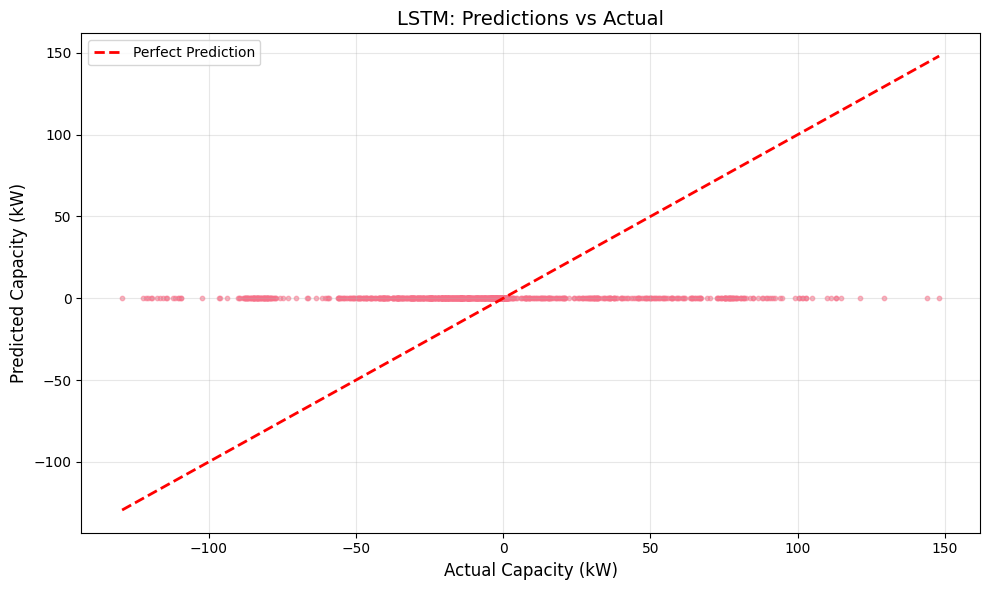

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(targets, predictions, alpha=0.5, s=10)

# Perfect prediction line
min_val = min(targets.min(), predictions.min())
max_val = max(targets.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Capacity (kW)', fontsize=12)
plt.ylabel('Predicted Capacity (kW)', fontsize=12)
plt.title('LSTM: Predictions vs Actual', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.2 Time Series Comparison (First 500 samples)

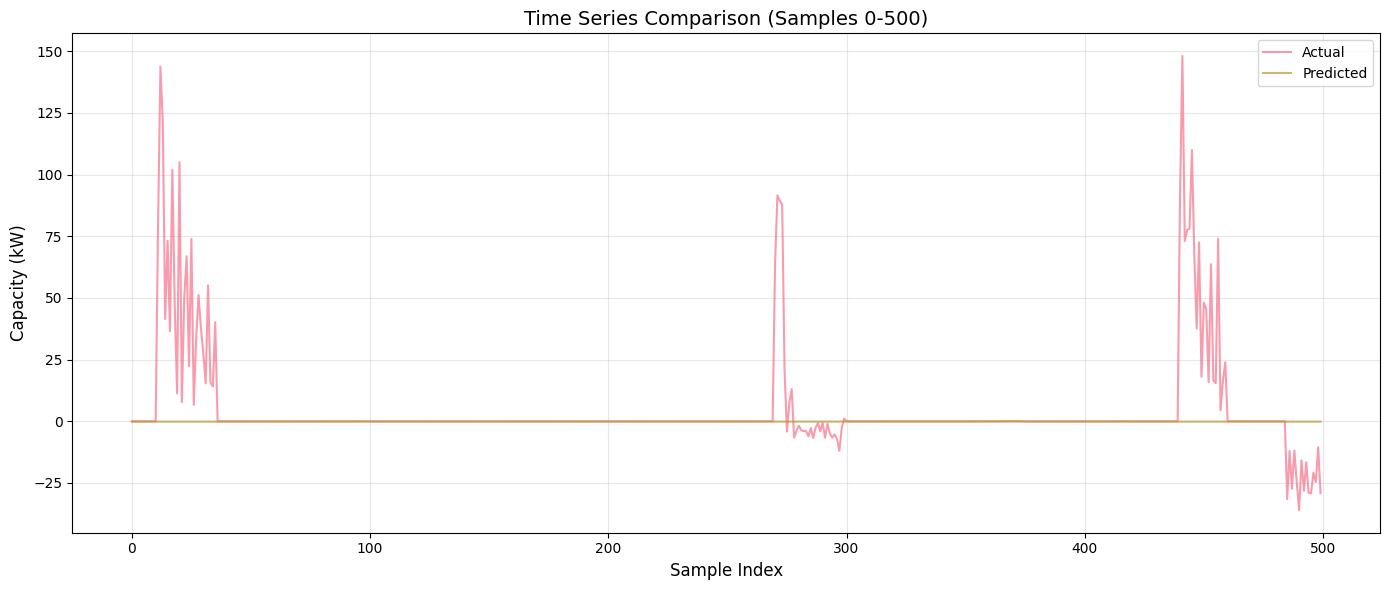

In [12]:
sample_start = 0
sample_end = 500

plt.figure(figsize=(14, 6))
x = np.arange(sample_start, min(sample_end, len(targets)))
plt.plot(x, targets[sample_start:sample_end], label='Actual', alpha=0.7, linewidth=1.5)
plt.plot(x, predictions[sample_start:sample_end], label='Predicted', alpha=0.7, linewidth=1.5)

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Capacity (kW)', fontsize=12)
plt.title(f'Time Series Comparison (Samples {sample_start}-{sample_end})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Time Series Comparison (Samples 500-1000)

In [ ]:
sample_start = 500
sample_end = 1000

plt.figure(figsize=(14, 6))
x = np.arange(sample_start, min(sample_end, len(targets)))
plt.plot(x, targets[sample_start:sample_end], label='Actual', alpha=0.7, linewidth=1.5)
plt.plot(x, predictions[sample_start:sample_end], label='Predicted', alpha=0.7, linewidth=1.5)

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Capacity (kW)', fontsize=12)
plt.title(f'Time Series Comparison (Samples {sample_start}-{sample_end})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Residual Analysis

In [ ]:
residuals = predictions - targets

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(predictions, residuals, alpha=0.5, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Capacity (kW)', fontsize=12)
axes[0].set_ylabel('Residuals (kW)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (kW)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=14)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.5 Error by Prediction Magnitude

In [ ]:
# Create bins based on true values
n_bins = 10
bins = np.percentile(targets[targets > 0], np.linspace(0, 100, n_bins + 1))
bins = np.unique(bins)

bin_centers = []
bin_maes = []

for i in range(len(bins) - 1):
    mask = (targets >= bins[i]) & (targets < bins[i+1])
    if mask.sum() > 0:
        bin_centers.append((bins[i] + bins[i+1]) / 2)
        bin_maes.append(np.abs(targets[mask] - predictions[mask]).mean())

plt.figure(figsize=(10, 6))
plt.plot(bin_centers, bin_maes, marker='o', linewidth=2, markersize=8)
plt.xlabel('Actual Capacity Range (kW)', fontsize=12)
plt.ylabel('Mean Absolute Error (kW)', fontsize=12)
plt.title('Error by Prediction Magnitude', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Custom Analysis (Optional)
Add your own analysis cells below

In [ ]:
# Example: Analyze specific time range
# You can modify sample_start and sample_end to zoom into specific regions

sample_start = 200
sample_end = 300

plt.figure(figsize=(14, 6))
x = np.arange(sample_start, min(sample_end, len(targets)))
plt.plot(x, targets[sample_start:sample_end], 'o-', label='Actual', alpha=0.7, linewidth=2, markersize=4)
plt.plot(x, predictions[sample_start:sample_end], 's-', label='Predicted', alpha=0.7, linewidth=2, markersize=4)

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Capacity (kW)', fontsize=12)
plt.title(f'Detailed View: Samples {sample_start}-{sample_end}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Example: Print worst predictions
errors = np.abs(targets - predictions)
worst_indices = np.argsort(errors)[-10:][::-1]

print("Top 10 Worst Predictions:")
print("=" * 60)
for idx in worst_indices:
    print(f"Index {idx}: Actual={targets[idx]:.2f} kW, Predicted={predictions[idx]:.2f} kW, Error={errors[idx]:.2f} kW")

In [ ]:
# Example: Analyze predictions by demand response flag
for flag in [-1, 0, 1]:
    mask = val_demand_flags == flag
    if mask.sum() > 0:
        flag_mae = np.abs(targets[mask] - predictions[mask]).mean()
        print(f"Demand Flag {flag}: {mask.sum()} samples, MAE = {flag_mae:.4f} kW")

## 10. Summary
Run this cell to get a final summary

In [ ]:
print("\n" + "=" * 80)
print("EVALUATION SUMMARY")
print("=" * 80)

print(f"\nModel: {MODEL_CHECKPOINT}")
print(f"Architecture: {MODEL_CONFIG['num_layers']} layers, {MODEL_CONFIG['hidden_size']} hidden units")
print(f"\nValidation Samples: {len(predictions)}")
print(f"\nKey Metrics:")
print(f"  • NMAE (mean): {metrics['nmae_mean']:.2f}%")
print(f"  • MAE: {mae:.4f} kW")
print(f"  • RMSE: {rmse:.4f} kW")
print(f"  • F1 Score: {metrics['f1_score']:.4f}")
print(f"  • Prediction Std: {predictions.std():.4f} kW")

if predictions.std() < 1.0:
    print(f"\n⚠️  WARNING: Model produces nearly horizontal predictions!")
elif metrics['nmae_mean'] < 30:
    print(f"\n✅ Model performance looks good!")
elif metrics['nmae_mean'] < 40:
    print(f"\n🔶 Model performance is acceptable, but could be improved.")
else:
    print(f"\n❌ Model performance needs improvement.")

print("=" * 80)